<a href="https://colab.research.google.com/github/wahyuwinanta/WeldingApp/blob/main/notebooks/yolov8n-instance-segmentation-v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sat May 30 10:32:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   29C    P0             48W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics roboflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 154.7 MB/s eta 0:00:00


In [3]:
import os
import shutil
import random
import glob
import cv2
import math
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict
from ultralytics import YOLO
from IPython.display import display, Image
from sklearn.metrics import confusion_matrix, classification_report

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
HOME = os.getcwd() # Define HOME here to ensure it's available

In [5]:
# Download Dataset dari Roboflow (Pastikan ganti API Key & Project Anda)
from roboflow import Roboflow
rf = Roboflow(api_key="YvnVogcaoID0j5yIz1sU")
project = rf.workspace("skripsi-0vmgq").project("cacatpengelasan")
dataset = project.version(6).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to CacatPengelasan-6 in yolov8:: 100%|██████████| 3603/3603 [00:00<00:00, 29835.52it/s]


In [6]:
print("\n=== INFORMASI DATASET ROBOLOFLOW ===")
train_img_path = os.path.join(dataset.location, "train", "images")
train_label_path = os.path.join(dataset.location, "train", "labels")

if os.path.exists(train_img_path):
    num_images = len(glob.glob(os.path.join(train_img_path, "*.jpg")))
    num_labels = len(glob.glob(os.path.join(train_label_path, "*.txt")))
    print(f"Lokasi Dataset : {dataset.location}")
    print(f"Jumlah Gambar  : {num_images}")
    print(f"Jumlah Label   : {num_labels}")
else:
    print("Folder training tidak ditemukan!")


=== INFORMASI DATASET ROBOLOFLOW ===
Lokasi Dataset : /content/CacatPengelasan-6
Jumlah Gambar  : 1800
Jumlah Label   : 1800


In [7]:
# 3. Load Nama Kelas dari data.yaml
with open(os.path.join(dataset.location, "data.yaml"), 'r') as f:
    data_conf = yaml.safe_load(f)
    class_names = data_conf['names']

print(f"Daftar Kelas   : {class_names}")

Daftar Kelas   : ['Excess', 'Good Welding', 'Undercut']


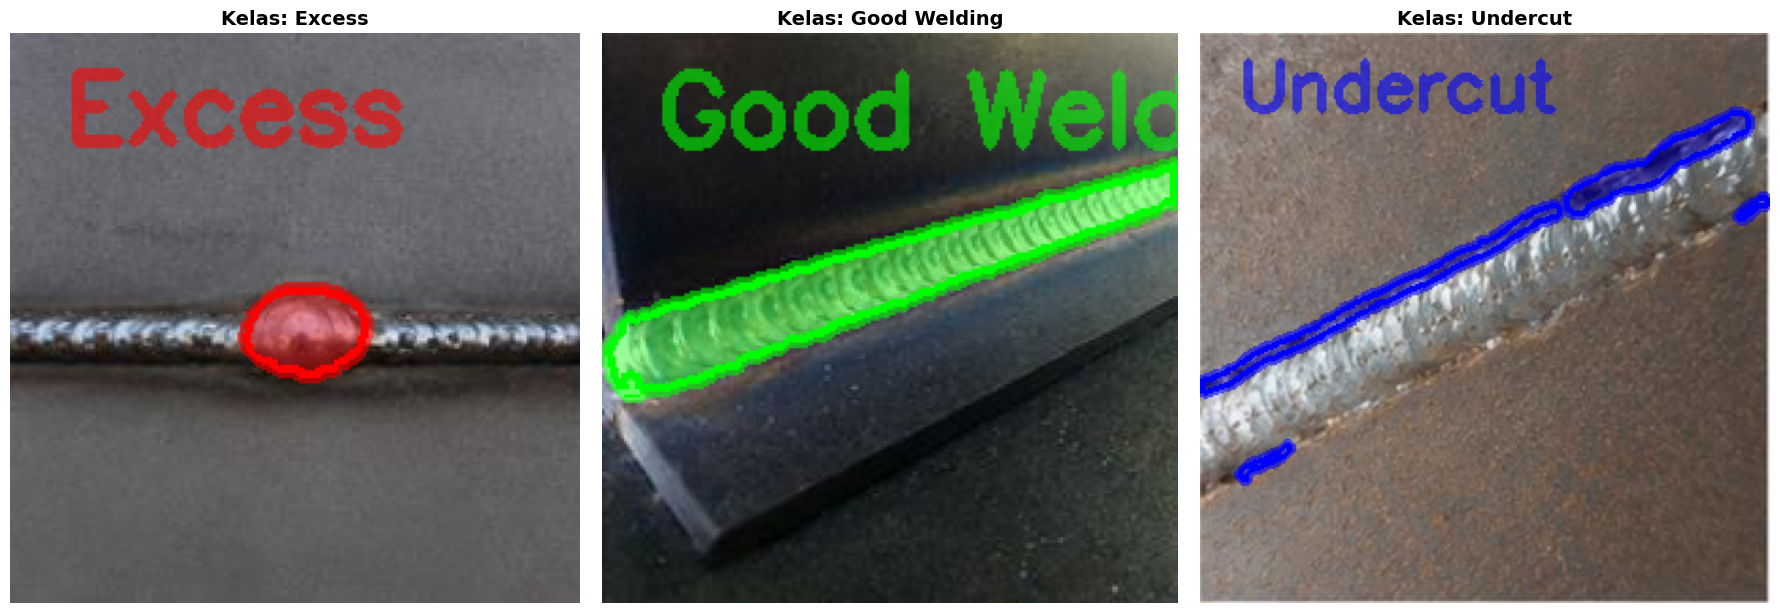

In [9]:
def plot_samples_per_class(img_dir, label_dir, class_names):
    # Setup warna unik untuk 3 kelas Anda
    # Excess (Merah), Good Welding (Hijau), Undercut (Biru)
    class_colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]

    # Mencari satu gambar contoh untuk setiap ID kelas
    samples_to_show = {} # {class_id: img_path}
    all_label_files = glob.glob(os.path.join(label_dir, "*.txt"))

    for label_path in all_label_files:
        with open(label_path, 'r') as f:
            first_line = f.readline().strip()
            if first_line:
                class_id = int(first_line.split()[0])
                if class_id not in samples_to_show:
                    img_path = label_path.replace("labels", "images").replace(".txt", ".jpg")
                    if os.path.exists(img_path):
                        samples_to_show[class_id] = img_path

        # Berhenti jika semua kelas sudah punya contoh
        if len(samples_to_show) == len(class_names):
            break

    num_classes = len(class_names)
    plt.figure(figsize=(18, 6))

    for i, class_id in enumerate(sorted(samples_to_show.keys())):
        img_path = samples_to_show[class_id]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        overlay = img.copy()
        h, w, _ = img.shape

        label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")

        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                current_class_id = int(parts[0])

                if current_class_id == class_id:
                    color = class_colors[class_id % len(class_colors)]
                    coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)
                    coords[:, 0] *= w
                    coords[:, 1] *= h
                    pts = coords.astype(np.int32).reshape((-1, 1, 2))

                    cv2.fillPoly(overlay, [pts], color)
                    cv2.polylines(img, [pts], isClosed=True, color=color, thickness=3)
                    cv2.putText(img, class_names[class_id], (20, 40),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)

        alpha = 0.4
        img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

        plt.subplot(1, num_classes, i + 1)
        plt.imshow(img)
        plt.title(f"Kelas: {class_names[class_id]}", fontsize=14, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

class_names = ['Excess', 'Good Welding', 'Undercut']
plot_samples_per_class(train_img_path, train_label_path, class_names)

In [10]:
def split_dataset_stratified(source_path, train_count=420, val_count=120, test_count=60):
    base_dir = os.path.join(HOME, 'split_dataset')

    for split in ['train', 'valid', 'test']:
        for sub in ['images', 'labels']:
            os.makedirs(os.path.join(base_dir, split, sub), exist_ok=True)

    category_map = defaultdict(list)
    image_files = glob.glob(os.path.join(source_path, 'train/images/*.jpg'))

    for img_path in image_files:
        label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                first_line = f.readline().strip()
                if first_line:
                    class_id = int(first_line.split()[0])
                    category_map[class_id].append(img_path)

    for class_id, files in category_map.items():
        random.shuffle(files)

        train_files = files[:train_count]
        val_files = files[train_count : train_count + val_count]
        test_files = files[train_count + val_count : train_count + val_count + test_count]

        split_assignment = {
            'train': train_files,
            'valid': val_files,
            'test': test_files
        }

        for split_name, selected_files in split_assignment.items():
            for img_path in selected_files:
                fname = os.path.basename(img_path)
                shutil.copy(img_path, os.path.join(base_dir, split_name, 'images', fname))
                label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
                shutil.copy(label_path, os.path.join(base_dir, split_name, 'labels', fname.replace('.jpg', '.txt')))

    print(f"Stratified Splitting selesai!")
    print(f"Target per kelas -> Train: {train_count}, Valid: {val_count}, Test: {test_count}")
    return base_dir

new_dataset_path = split_dataset_stratified(dataset.location)

Stratified Splitting selesai!
Target per kelas -> Train: 420, Valid: 120, Test: 60


In [11]:
# Update file data.yaml agar mengarah ke folder baru

with open(f"{dataset.location}/data.yaml", 'r') as f:
    data_yaml = yaml.safe_load(f)

data_yaml['train'] = os.path.join(new_dataset_path, 'train/images')
data_yaml['val'] = os.path.join(new_dataset_path, 'valid/images')
data_yaml['test'] = os.path.join(new_dataset_path, 'test/images')

with open(f"{new_dataset_path}/data.yaml", 'w') as f:
    yaml.dump(data_yaml, f)

print(f"Dataset berhasil dibagi! Lokasi: {new_dataset_path}")

Dataset berhasil dibagi! Lokasi: /content/split_dataset


In [12]:
def proses_lanczos_upscale(base_path):
    splits = ['train', 'valid', 'test']
    total_images_processed = 0

    print("\n=== MEMULAI PROSES UPSCALING & PENAJAMAN GAMBAR (LANCZOS) ===")

    for split in splits:
        img_folder = os.path.join(base_path, split, 'images')
        if not os.path.exists(img_folder):
            continue

        img_paths = glob.glob(os.path.join(img_folder, "*.jpg")) + glob.glob(os.path.join(img_folder, "*.png"))
        print(f"Mengubah ukuran {len(img_paths)} gambar di folder '{split}' dari 280 ke 640...")

        for p in img_paths:
            img = cv2.imread(p)
            if img is None:
                continue

            # Mengubah 280x280 ke 640x640 menggunakan Interpolasi Lanczos agar tidak buram
            high_res = cv2.resize(img, (640, 640), interpolation=cv2.INTER_LANCZOS4)

            # Simpan kembali menimpa file gambar lama
            cv2.imwrite(p, high_res)
            total_images_processed += 1

    print(f"Selesai! Total {total_images_processed} gambar berhasil di-upscale secara bersih.\n")

# Eksekusi fungsi penajaman gambar massal sebelum training dimulai
proses_lanczos_upscale(new_dataset_path)


=== MEMULAI PROSES UPSCALING & PENAJAMAN GAMBAR (LANCZOS) ===
Mengubah ukuran 1260 gambar di folder 'train' dari 280 ke 640...
Mengubah ukuran 360 gambar di folder 'valid' dari 280 ke 640...
Mengubah ukuran 180 gambar di folder 'test' dari 280 ke 640...
Selesai! Total 1800 gambar berhasil di-upscale secara bersih.



In [13]:
print("=== JUMLAH GAMBAR & VERIFIKASI DIMENSI PER SPLIT ===")
splits = ['train', 'valid', 'test']
total_images_all = 0

for split in splits:
    img_path = os.path.join(new_dataset_path, split, 'images')

    if os.path.exists(img_path):
        sample_files = glob.glob(os.path.join(img_path, '*.jpg'))
        num_images = len(sample_files)
        total_images_all += num_images

        # Mengambil sampel resolusi untuk verifikasi ukuran akhir
        dimensi_str = "Unknown"
        if num_images > 0:
            sample_img = cv2.imread(sample_files[0])
            dimensi_str = f"{sample_img.shape[1]}x{sample_img.shape[0]}"

        percentage = (num_images / 1800) * 100
        print(f"--- {split.capitalize()} Set ---")
        print(f"  Jumlah Gambar : {num_images} file ({percentage:.1f}%)")
        print(f"  Resolusi Fisik: {dimensi_str} piksel")
    else:
        print(f"--- {split.capitalize()} Set ---")
        print(f"  Folder tidak ditemukan!")

print("\n------------------------------")
print(f"TOTAL SELURUH GAMBAR : {total_images_all} file")

=== JUMLAH GAMBAR & VERIFIKASI DIMENSI PER SPLIT ===
--- Train Set ---
  Jumlah Gambar : 1260 file (70.0%)
  Resolusi Fisik: 640x640 piksel
--- Valid Set ---
  Jumlah Gambar : 360 file (20.0%)
  Resolusi Fisik: 640x640 piksel
--- Test Set ---
  Jumlah Gambar : 180 file (10.0%)
  Resolusi Fisik: 640x640 piksel

------------------------------
TOTAL SELURUH GAMBAR : 1800 file


In [15]:
import re

def bersihkan_label_non_segmentasi(base_path):
    splits = ['train', 'valid', 'test']
    file_diperbaiki = 0

    print("\n=== MEMULAI SANITASI DATASET UNTUK INSTANCE SEGMENTATION ===")

    for split in splits:
        label_folder = os.path.join(base_path, split, 'labels')
        if not os.path.exists(label_folder):
            continue

        label_paths = glob.glob(os.path.join(label_folder, "*.txt"))

        for p in label_paths:
            baris_valid = []
            perubahan = False

            with open(p, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 3:
                    continue

                # Format YOLO Segmentation minimal harus memiliki lebih dari 6 nilai (Class ID + minimal 3 titik XY)
                # Jika parts hanya berisi 5 nilai (Class_ID, X_center, Y_center, Width, Height), itu adalah Bounding Box biasa
                if len(parts) <= 5:
                    perubahan = True
                    continue # Lewati / hapus baris yang hanya berbentuk bounding box biasa

                baris_valid.append(line)

            # Jika ditemukan label box biasa, timpa file dengan data segmentasi yang bersih saja
            if perubahan:
                with open(p, 'w') as f:
                    f.writelines(baris_valid)
                file_diperbaiki += 1

    print(f"Sanitasi selesai! Berhasil membersihkan {file_diperbaiki} file label yang tidak memiliki koordinat segmentasi.\n")

In [16]:
bersihkan_label_non_segmentasi(new_dataset_path)


=== MEMULAI SANITASI DATASET UNTUK INSTANCE SEGMENTATION ===
Sanitasi selesai! Berhasil membersihkan 270 file label yang tidak memiliki koordinat segmentasi.



In [17]:
model = YOLO('yolov8n-seg.pt')

results = model.train(
    data=f"{new_dataset_path}/data.yaml",
    epochs=150,
    imgsz=640,
    device=0,
    name='yolov8_custom_seg',
    patience=20,
    retina_masks=True,
    exist_ok=True
)

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/split_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_custom_seg, nbs=64, nms=False, opset=None, optimize=Fal

KeyboardInterrupt: 

In [ ]:
def tampilkan_semua_salah_prediksi(model_path, data_test_path, conf_threshold=0.25):
    # 1. Load Model
    model = YOLO(model_path)
    class_names = ['Excess', 'Good Welding', 'Undercut']

    # 2. Ambil semua gambar dari folder test
    image_paths = glob.glob(os.path.join(data_test_path, "*.jpg"))
    misclassified_images = []

    print(f"Menganalisis {len(image_paths)} gambar di folder test...")

    for img_path in image_paths:
        results = model.predict(source=img_path, conf=conf_threshold, verbose=False)
        result = results[0]

        # Ambil Label Asli (Ground Truth)
        label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
        if not os.path.exists(label_path): continue

        with open(label_path, 'r') as f:
            lines = f.readlines()
            if not lines: continue
            true_class_id = int(lines[0].split()[0])

        # Logika Deteksi Kesalahan
        if len(result.boxes) > 0:
            pred_class_id = int(result.boxes.cls[0].item())
            confidence = result.boxes.conf[0].item()

            if true_class_id != pred_class_id:
                misclassified_images.append({
                    'path': img_path,
                    'true': class_names[true_class_id],
                    'pred': class_names[pred_class_id],
                    'conf': confidence
                })
        else:
            # Opsional: Jika gambar aslinya ada objek tapi model tidak deteksi sama sekali (False Negative)
            # Anda bisa menambahkan ini ke daftar salah jika ingin melihat yang "luput" deteksi
            misclassified_images.append({
                'path': img_path,
                'true': class_names[true_class_id],
                'pred': "Tidak Terdeteksi",
                'conf': 0.0
            })

    # 3. Visualisasi dalam bentuk Grid
    num_errors = len(misclassified_images)
    if num_errors == 0:
        print("Luar biasa! Tidak ada kesalahan prediksi ditemukan.")
        return

    print(f"Ditemukan {num_errors} kesalahan prediksi. Menampilkan grid...")

    # Tentukan jumlah kolom (misal 4) dan hitung baris yang dibutuhkan
    cols = 4
    rows = math.ceil(num_errors / cols)

    plt.figure(figsize=(20, 5 * rows))
    for i, item in enumerate(misclassified_images):
        img = cv2.imread(item['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"File: {os.path.basename(item['path'])}\nASLI: {item['true']} | TEBAK: {item['pred']}\nConf: {item['conf']:.2f}",
                  color='red', fontsize=10, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- JALANKAN ---
PATH_MODEL = '/content/runs/segment/yolov8_custom_seg/weights/best.pt'
PATH_TEST_IMAGES = '/content/split_dataset/test/images'

tampilkan_semua_salah_prediksi(PATH_MODEL, PATH_TEST_IMAGES)

In [ ]:
metrics = model.val()

# Menghitung Kecepatan (Inference Time & FPS)
# YOLOv8 menyimpan waktu dalam ms: [preprocess, inference, loss, postprocess]
t_preprocess = metrics.speed['preprocess']
t_inference = metrics.speed['inference']
t_postprocess = metrics.speed['postprocess']
total_time_ms = t_preprocess + t_inference + t_postprocess
fps = 1000 / total_time_ms

# Membuat Tabel Ringkasan untuk Laporan Skripsi
summary_data = {
    "Matriks Evaluasi": ["mAP@50 (B)", "mAP@50-95 (B)", "mAP@50 (M)", "mAP@50-95 (M)",
                         "Inference Time", "Kecepatan (FPS)"],
    "Nilai": [
        f"{metrics.box.map50:.4f}",
        f"{metrics.box.map:.4f}",
        f"{metrics.seg.map50:.4f}",
        f"{metrics.seg.map:.4f}",
        f"{total_time_ms:.2f} ms/img",
        f"{fps:.2f} FPS"
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\n=== TABEL EVALUASI MODEL  ===")
display(df_summary)

In [ ]:
RESULT_DIR = f"{HOME}/runs/segment/yolov8_custom_seg"

def show_eval_graphics():
    graphics = [
        ("results.png", "Grafik Training Loss & Accuracy"),
        ("confusion_matrix.png", "Confusion Matrix"),
        ("F1_curve.png", "F1-Score Curve"),
        ("PR_curve.png", "Precision-Recall Curve")
    ]

    for filename, title in graphics:
        img_path = os.path.join(RESULT_DIR, filename)
        if os.path.exists(img_path):
            plt.figure(figsize=(12, 8))
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
            plt.title(title, fontsize=15, fontweight='bold')
            plt.axis('off')
            plt.show()
        else:
            print(f"⚠️ Grafik {filename} tidak ditemukan di {RESULT_DIR}")

# Eksekusi Bagian 1
show_eval_graphics()

In [ ]:
def calculate_detailed_metrics(model_path, data_yaml):
    # 1. Load Model Terbaik
    model = YOLO(model_path)

    # 2. Jalankan Validasi
    print("Sedang menghitung metrik evaluasi...")
    results = model.val(data=data_yaml, split='val')

    # 3. Ambil Nama Kelas
    class_names = list(results.names.values())

    # 4. Ambil Metrik (Box/Detection)
    # Precision, Recall, mAP50
    p = results.results_dict['metrics/precision(B)']
    r = results.results_dict['metrics/recall(B)']
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

    # Metrik Per Kelas
    per_class_p = results.box.p.tolist()
    per_class_r = results.box.r.tolist()

    data_metrics = []
    for i, name in enumerate(class_names):
        cp = per_class_p[i]
        cr = per_class_r[i]
        cf1 = 2 * (cp * cr) / (cp + cr) if (cp + cr) > 0 else 0

        data_metrics.append({
            "Class": name,
            "Precision": f"{cp:.4f}",
            "Recall": f"{cr:.4f}",
            "F1-Score": f"{cf1:.4f}"
        })

    # Tambahkan Nilai Keseluruhan (All Classes)
    data_metrics.append({
        "Class": "--- ALL CLASSES ---",
        "Precision": f"{p:.4f}",
        "Recall": f"{r:.4f}",
        "F1-Score": f"{f1:.4f}"
    })

    # 5. Tampilkan dalam bentuk Tabel
    df = pd.DataFrame(data_metrics)
    print("\n=== TABEL EVALUASI METRIK (DETEKSI) ===")
    print(df.to_string(index=False))

    # Note untuk skripsi: Accuracy dalam Object Detection sering direpresentasikan oleh mAP
    print(f"\nMean Average Precision (mAP50): {results.results_dict['metrics/mAP50(B)']:.4f}")

# Eksekusi Bagian 2
# Sesuaikan path data_yaml Anda
MODEL_BEST = os.path.join(RESULT_DIR, 'weights/best.pt')
DATA_YAML = f"{new_dataset_path}/data.yaml"

calculate_detailed_metrics(MODEL_BEST, DATA_YAML)

In [ ]:
# Membaca file results.csv yang dihasilkan saat training
results_csv_path = os.path.join(RESULT_DIR, 'results.csv')

if os.path.exists(results_csv_path):
    results_df = pd.read_csv(results_csv_path)
    results_df.columns = results_df.columns.str.strip() # Bersihkan spasi pada nama kolom

    # Ambil baris terakhir (hasil akhir training)
    last_loss = results_df.iloc[-1]

    print("\n=== DETAIL LOSS FUNCTION (FINAL EPOCH) ===")
    print(f"Train Box Loss  : {last_loss['train/box_loss']:.4f}")
    print(f"Train Class Loss: {last_loss['train/cls_loss']:.4f}")
    print(f"Train DFL Loss  : {last_loss['train/dfl_loss']:.4f}")
    print("-" * 40)
    print(f"Val Box Loss    : {last_loss['val/box_loss']:.4f}")
    print(f"Val Class Loss  : {last_loss['val/cls_loss']:.4f}")
    print(f"Val DFL Loss    : {last_loss['val/dfl_loss']:.4f}")

In [ ]:
# Load Model Terbaik (Hasil Training)
# Pastikan path ini sesuai dengan lokasi file best.pt Anda
HOME = os.getcwd()
model_path = f"{HOME}/runs/segment/yolov8_custom_seg/weights/best.pt"

if os.path.exists(model_path):
    model = YOLO(model_path)
    print("Model berhasil dimuat!")
else:
    print("Model tidak ditemukan! Periksa kembali path file best.pt Anda.")

# Menentukan Sumber Data Uji (Test Set)
# Kita gunakan folder 'test' yang dibuat saat proses splitting sebelumnya
test_images_path = f"{HOME}/split_dataset/test/images"
test_image_list = glob.glob(os.path.join(test_images_path, "*.jpg"))

if not test_image_list:
    print("Data uji tidak ditemukan di folder split_dataset/test/images")
else:
    # Menjalankan Prediksi (Inference)
    # Kita ambil 3 sampel acak untuk divisualisasikan
    samples = random.sample(test_image_list, min(3, len(test_image_list)))

    print(f"Menjalankan tes pada {len(samples)} sampel gambar...")

    # Jalankan prediksi
    results = model.predict(
        source=samples,
        conf=0.25,        # Ambang batas kepercayaan (bisa disesuaikan)
        save=True,        # Simpan hasil visualisasi
        line_width=2,     # Ketebalan garis box
        name="final_test_results",
        exist_ok=True
    )

    # Menampilkan Hasil Visualisasi
    print("\n=== HASIL VISUALISASI TES ===")
    prediction_dir = f"{HOME}/runs/segment/final_test_results"

    for res_img in glob.glob(os.path.join(prediction_dir, "*.jpg")):
        display(Image(filename=res_img, width=600))
        print(f"File: {os.path.basename(res_img)}\n")

# Ekstraksi Data Prediksi (Opsional - Untuk Analisis Tabel)
# Contoh mengambil koordinat mask dan box dari gambar pertama
if 'results' in locals():
    first_res = results[0]
    print("--- Analisis Data Gambar Pertama ---")
    print(f"Jumlah Objek Terdeteksi: {len(first_res.boxes)}")
    if first_res.masks is not None:
        print(f"Status Segmentasi: Sukses (Masks ditemukan)")
        # Menampilkan class ID yang terdeteksi
        for box in first_res.boxes:
            class_id = int(box.cls[0])
            conf = float(box.conf[0])
            print(f" - Kelas: {model.names[class_id]} (Conf: {conf:.2f})")

In [ ]:
# Load Model
model_path = f"{os.getcwd()}/runs/segment/yolov8_custom_seg/weights/best.pt"
model = YOLO(model_path)

# Jalankan Prediksi pada satu gambar
# Ganti path_gambar dengan lokasi gambar yang ingin diuji
path_gambar = "/content/split_dataset/test/images/good_welding-146-_png.rf.5a5fec757b34c466dd23246b9c56ad08.jpg"
results = model.predict(source=path_gambar, conf=0.25, save=False)

res = results[0]

# Proses Ekstraksi Piksel
if res.masks is not None:
    # Ambil gambar asli
    img = res.orig_img

    # Buat kanvas hitam dengan ukuran yang sama dengan gambar asli
    final_mask = np.zeros(img.shape[:2], dtype=np.uint8)

    # Gabungkan semua masker jika ada lebih dari satu objek terdeteksi
    for mask in res.masks.data:
        # Resize masker ke ukuran asli gambar
        m = mask.cpu().numpy()
        m = cv2.resize(m, (img.shape[1], img.shape[0]))
        final_mask = np.maximum(final_mask, m)

    # Ubah masker menjadi format biner (0 atau 255)
    final_mask = (final_mask > 0).astype(np.uint8) * 255

    # Gunakan operasi Bitwise AND untuk mengambil piksel asli berdasarkan masker
    # Piksel di luar masker akan otomatis menjadi hitam (0)
    segmented_img = cv2.bitwise_and(img, img, mask=final_mask)

    # Tampilkan Hasil
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Gambar Asli")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Hasil Segmentasi (Hanya Objek)")
    plt.imshow(cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

    # Simpan hasil jika diperlukan
    # cv2.imwrite("hasil_ekstraksi.png", segmented_img)
else:
    print("Tidak ada objek yang terdeteksi untuk disegmentasi.")

In [ ]:
import os
# Definisikan HOME kembali karena session di-restart
HOME = os.getcwd()
model_path = f"{HOME}/runs/segment/yolov8_custom_seg/weights/best.pt"

# Ekspor menggunakan CLI (lebih stabil) dan paksa CPU di level lingkungan
# Kita menggunakan 'int8=False' dan 'half=True' agar tetap Float16
!CUDA_VISIBLE_DEVICES="" yolo export model={model_path} format=tflite half=True device=cpu

In [ ]:
import zipfile
import os

def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                zipf.write(os.path.join(root, file),
                           os.path.relpath(os.path.join(root, file),
                           os.path.join(folder_path, '..')))

# Tentukan folder yang ingin di-zip (hasil training Anda)
folder_to_zip = '/content/runs/segment/yolov8_custom_seg'
output_zip = '/content/hasil_training_yolov8.zip'

zip_folder(folder_to_zip, output_zip)
print(f"Berhasil mengompres folder ke: {output_zip}")

In [ ]:
from google.colab import files

# 1. Download Folder ZIP (Semua hasil & grafik)
files.download('/content/hasil_training_yolov8.zip')

# 2. Download Model TFLite (Untuk aplikasi Android)
# Ganti path sesuai lokasi file TFLite Anda yang berhasil diekspor
tflite_path = '/content/runs/segment/yolov8_custom_seg/weights/best_saved_model/best_float16.tflite'
if os.path.exists(tflite_path):
    files.download(tflite_path)
else:
    print("File TFLite tidak ditemukan, pastikan proses ekspor berhasil.")